<a href="https://colab.research.google.com/github/nicolb21/TelecomX_parte2_Latam/blob/main/Telecom_X__Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analisis Churn  de clientes Telecom X Latam

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.


🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.



In [73]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick

print(f'Versión de pandas: {pd.__version__}')
print(f'Versión de numpy: {np.__version__}')
print(f'Versión de scikit-learn (sklearn): {sklearn.__version__}')
print(f'Versión de seaborn: {sns.__version__}')
print(f'Versión de yellowbrick: {yellowbrick.__version__}')

Versión de pandas: 2.2.2
Versión de numpy: 2.0.2
Versión de scikit-learn (sklearn): 1.6.1
Versión de seaborn: 0.13.2
Versión de yellowbrick: 1.5


In [74]:
datos = pd.read_csv("/content/datos_tratados.csv")

#ANALISIS EXPLORATORIO ANALITICO

In [75]:
datos.shape

(7032, 22)

In [76]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   Churn                7032 non-null   int64  
 2   gender               7032 non-null   object 
 3   SeniorCitizen        7032 non-null   int64  
 4   Partner              7032 non-null   int64  
 5   Dependents           7032 non-null   int64  
 6   Antiguedad_en_meses  7032 non-null   int64  
 7   PhoneService         7032 non-null   int64  
 8   MultipleLines        7032 non-null   object 
 9   InternetService      7032 non-null   object 
 10  OnlineSecurity       7032 non-null   object 
 11  OnlineBackup         7032 non-null   object 
 12  DeviceProtection     7032 non-null   object 
 13  TechSupport          7032 non-null   object 
 14  StreamingTV          7032 non-null   object 
 15  StreamingMovies      7032 non-null   o



```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object
 1   Churn             7043 non-null   object
 2   Gender            7043 non-null   object
 3   SeniorCitizen     7043 non-null   object
 4   Partner           7043 non-null   object
 5   Dependents        7043 non-null   object
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object
 8   MultipleLines     7043 non-null   object
 9   InternetService   7043 non-null   object
 10  OnlineSecurity    7043 non-null   object
 11  OnlineBackup      7043 non-null   object
 12  DeviceProtection  7043 non-null   object
 13  TechSupport       7043 non-null   object
 14  StreamingTV       7043 non-null   object
 15  StreamingMovies   7043 non-null   object
 16  Contract          7043 non-null   object
 17  PaperlessBilling  7043 non-null   object
 18  PaymentMethod     7043 non-null   object
 19  ChargesDaily      7043 non-null   float64
 20  ChargesMonthly    7043 non-null   float64
 21  ChargesTotal      7043 non-null   float64
dtypes: float64(3), int64(1), object(18)
memory usage: 1.2+ MB
```



#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `Antiguedad_en_meses`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente
- `Cuentas.Diarias`: gastado diario por el cliente

In [77]:
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas.Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [78]:
datos.describe()

,Churn,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas.Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [79]:
datos.describe(include='O') #→ nos muestra las variables categoricas

,customerID,gender,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


In [80]:
datos['gender'].value_counts(normalize=True)*100 # me lo da en %

,proportion
gender,
Male,50.469283
Female,49.530717


Nuestra variable RESPUESTA es Churn, la cual tenemos que predecir


#ANALISIS VISUAL DE LOS DATOS

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
churn_counts = datos['Churn'].value_counts()
churn_counts

,count
Churn,
0,5163
1,1869


Hay desbalanceo entre la clase

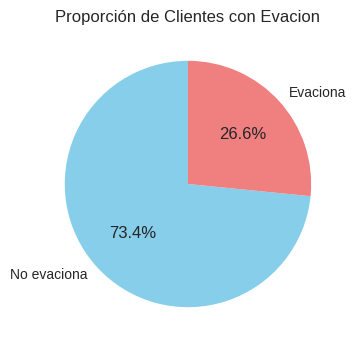

In [84]:
plt.figure(figsize=(4, 4))
plt.pie(churn_counts, labels=['No evaciona', 'Evaciona'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Proporción de Clientes con Evacion')
plt.show()

##**Antiguedad de los clientes**

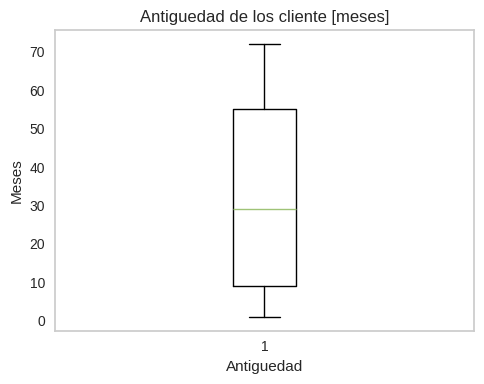

In [85]:
plt.figure(figsize=(5,4))

plt.boxplot(datos['Antiguedad_en_meses']) #grafica de la derecha
plt.title('Antiguedad de los cliente [meses]')
plt.xlabel('Antiguedad')
plt.ylabel('Meses')
plt.grid()


plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

Antiguedad vs Costo diario

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(


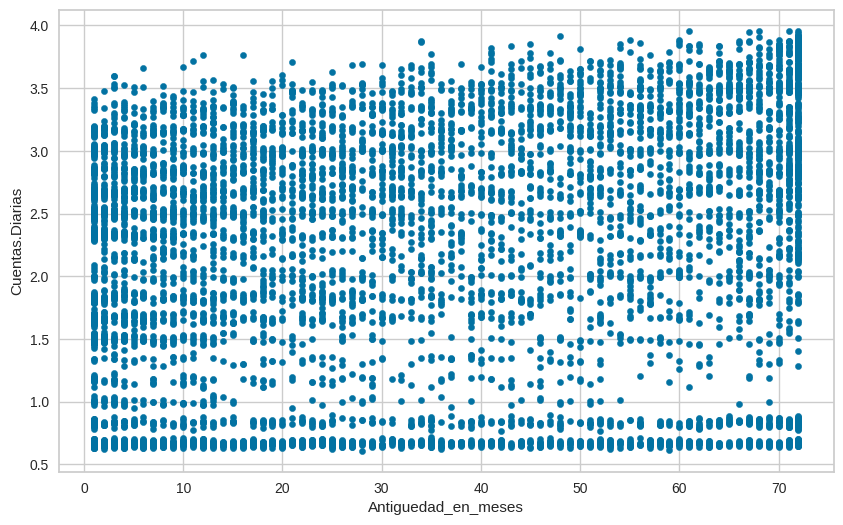

In [86]:
datos.plot(kind='scatter',x='Antiguedad_en_meses',y='Cuentas.Diarias',figsize=(10,6));

##**Distribucion de Evacion por Genero**

In [87]:
gender_churn_counts = datos.groupby(['gender', 'Churn']).size().unstack(fill_value=0)
display(gender_churn_counts)

Churn,0,1
gender,,
Female,2544,939
Male,2619,930


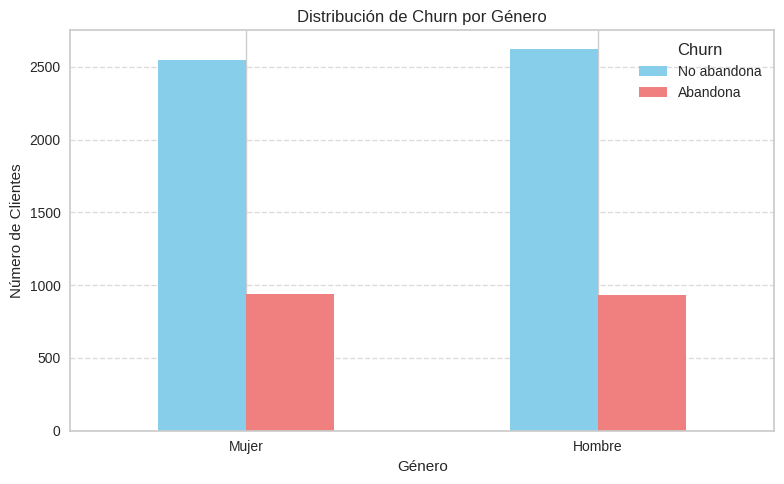

In [88]:
gender_churn_counts.plot(kind='bar', figsize=(8, 5), rot=0, color=['skyblue', 'lightcoral'])
plt.title('Distribución de Churn por Género')
plt.xlabel('Género')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['Mujer', 'Hombre'])
plt.legend(title='Churn', labels=['No abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**Distribucion de evacion por tipo de contrato**

In [89]:
contract_churn_counts = datos.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
display(contract_churn_counts)

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


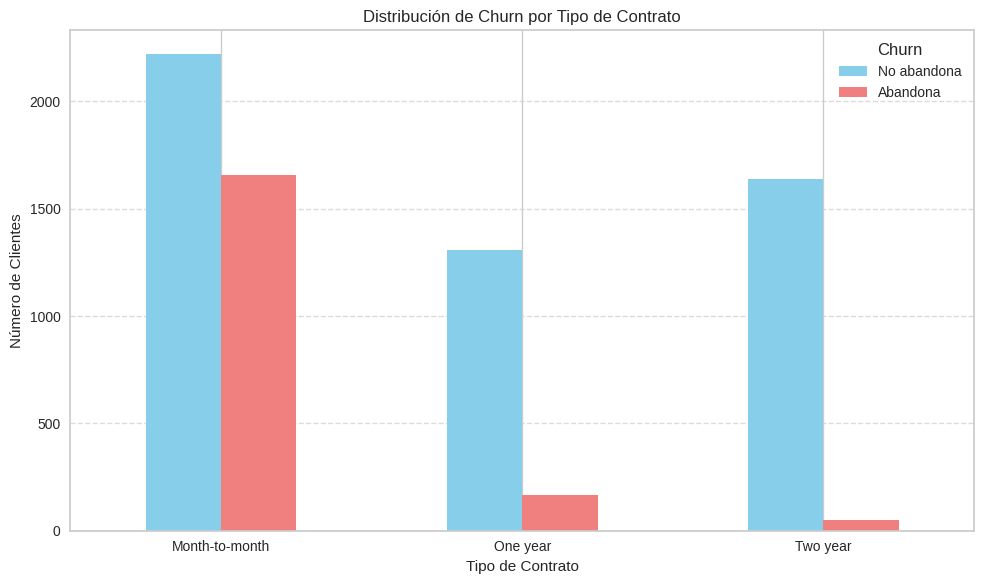

In [90]:
contract_churn_counts.plot(kind='bar', figsize=(10, 6), rot=0, color=['skyblue', 'lightcoral'])
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de Clientes')
plt.legend(title='Churn', labels=['No abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**Distribucion de Evacion por metodo de pago**

In [91]:
paymentmethod_churn_counts = datos.groupby(['PaymentMethod', 'Churn']).size().unstack(fill_value=0)
display(paymentmethod_churn_counts)

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


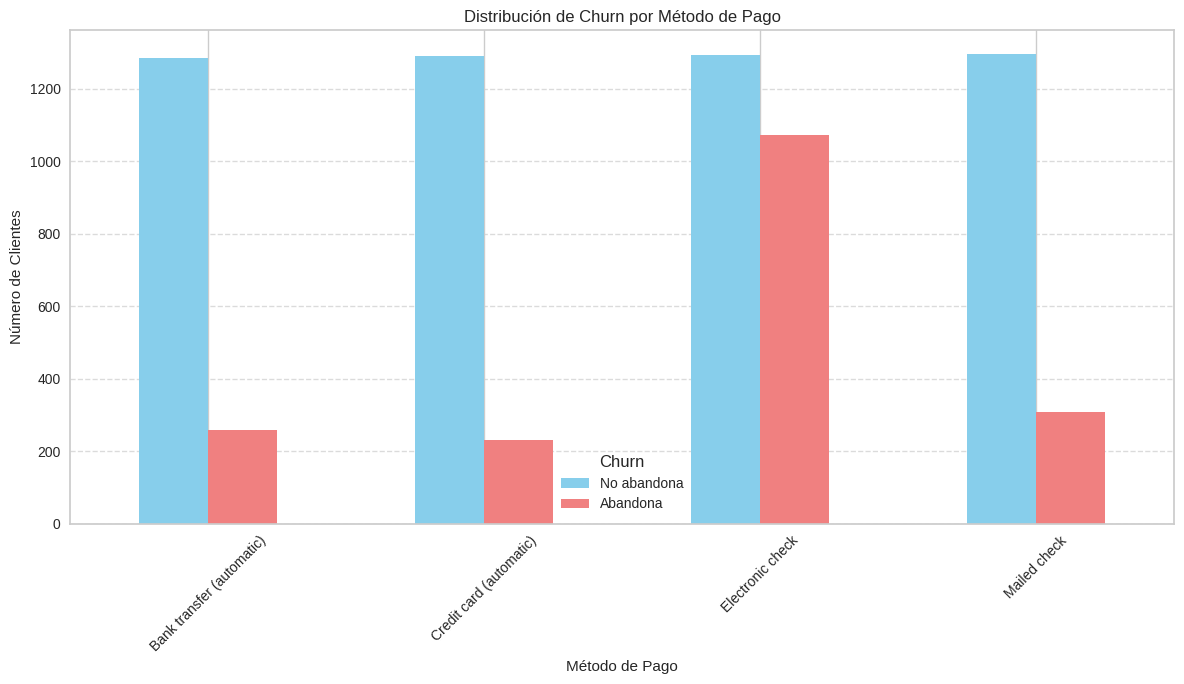

In [92]:
paymentmethod_churn_counts.plot(kind='bar', figsize=(12, 7), rot=45, color=['skyblue', 'lightcoral'])
plt.title('Distribución de Churn por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Número de Clientes')
plt.legend(title='Churn', labels=['No abandona', 'Abandona'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**Distribucion de Antiguedad/Cargas mesuales/Cargas totales/Cargos diaros por evacion**

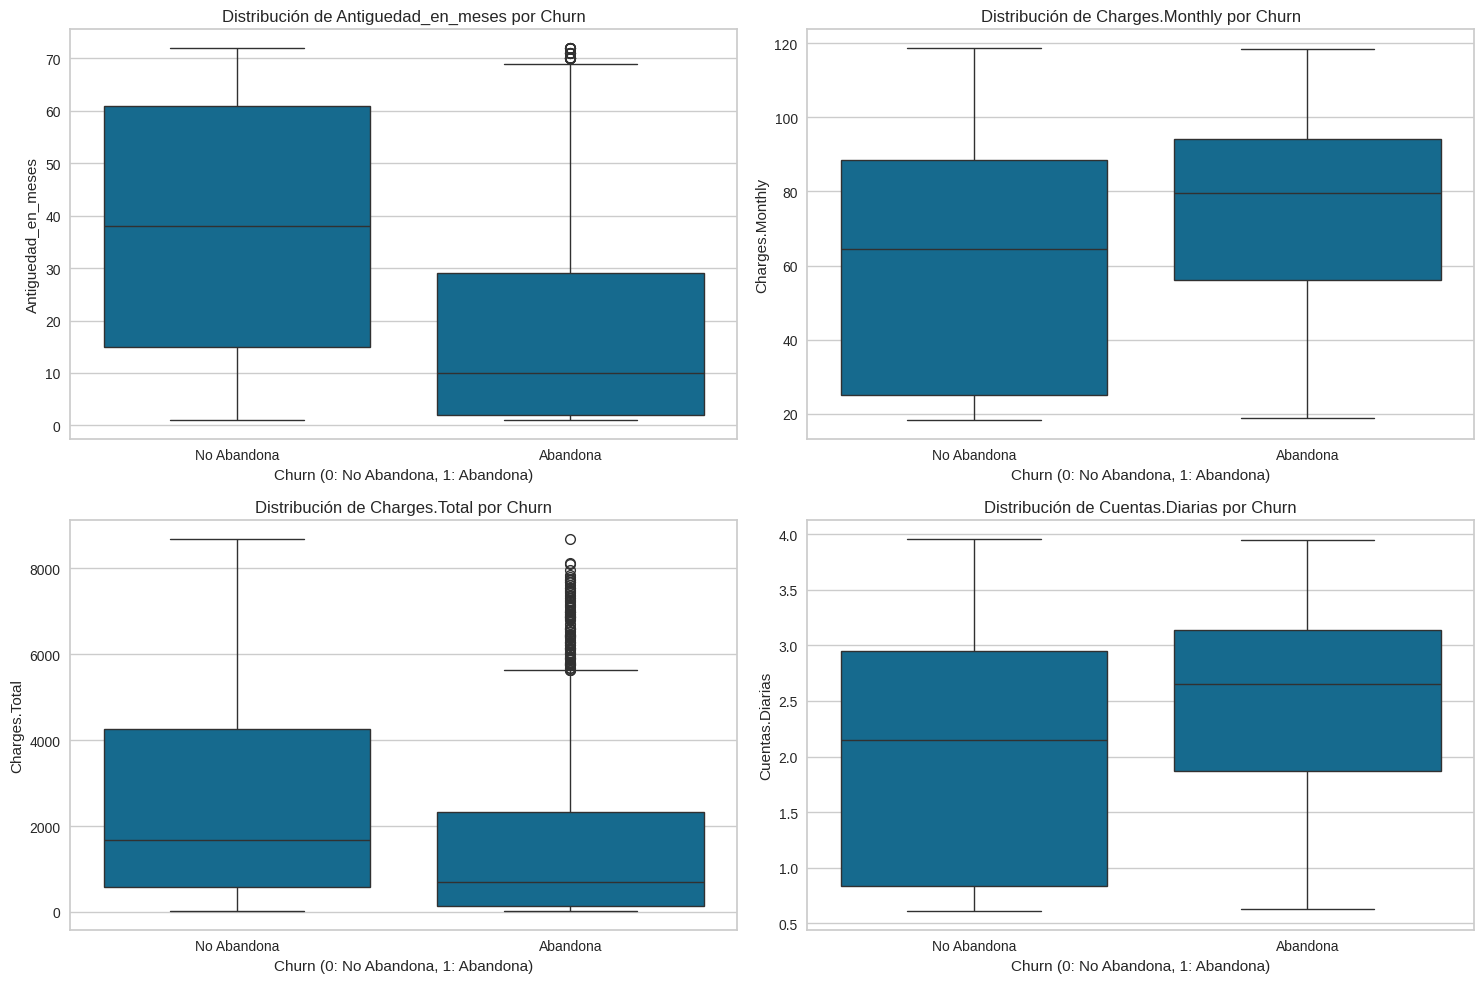

In [93]:
numerical_cols = ['Antiguedad_en_meses', 'Charges.Monthly', 'Charges.Total', 'Cuentas.Diarias']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='Churn', y=col, data=datos)
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel('Churn (0: No Abandona, 1: Abandona)')
    plt.ylabel(col)
    plt.xticks(ticks=[0, 1], labels=['No Abandona', 'Abandona'])
plt.tight_layout()
plt.show()

#COMO ESTAN DISTRIBUIDOS LOS DATOS

<Axes: xlabel='Charges.Total', ylabel='Count'>

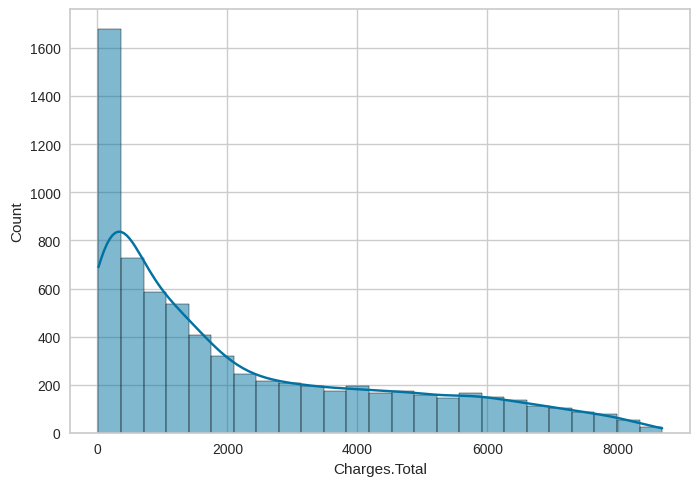

In [94]:
sns.histplot(data=datos,x='Charges.Total',kde=True)

<Axes: xlabel='Cuentas.Diarias', ylabel='Count'>

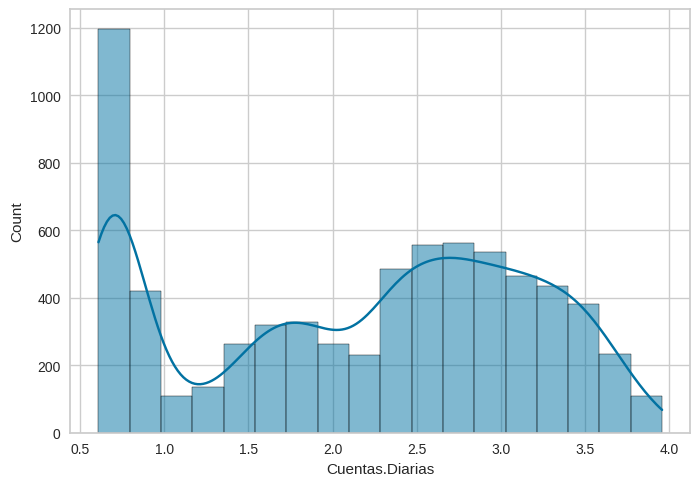

In [95]:
sns.histplot(data=datos,x='Cuentas.Diarias',kde=True)

otra forma...

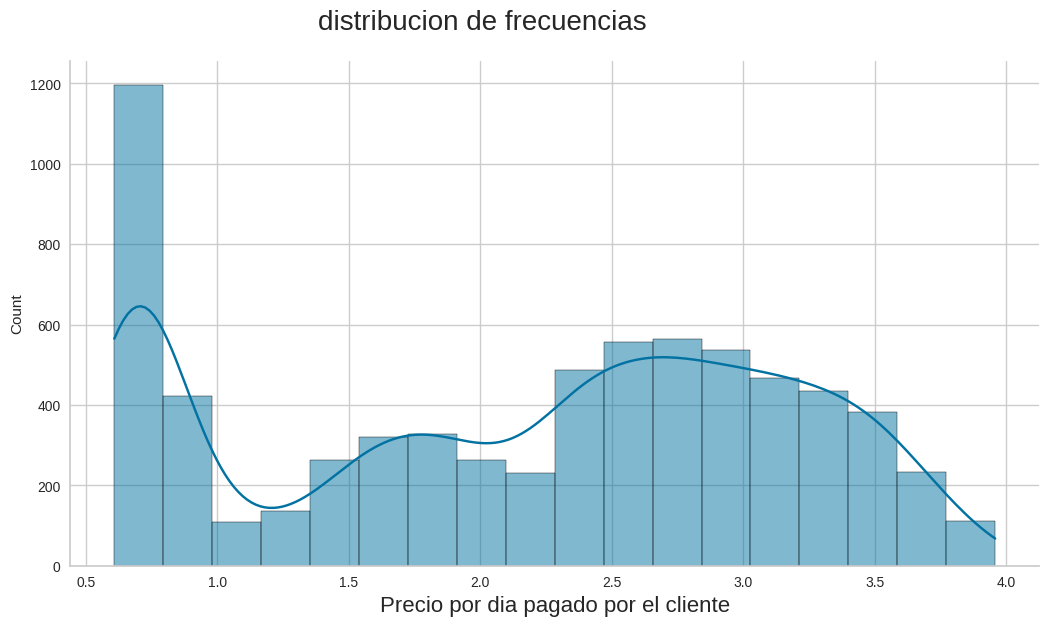

In [96]:
ax= sns.displot(datos['Cuentas.Diarias'],kde=True)
ax.figure.set_size_inches(12,6)
ax.fig.suptitle('distribucion de frecuencias',fontsize=20,y=1.05)
ax.set_xlabels('Precio por dia pagado por el cliente',fontsize=16)
ax;

Dispersion entre las variables

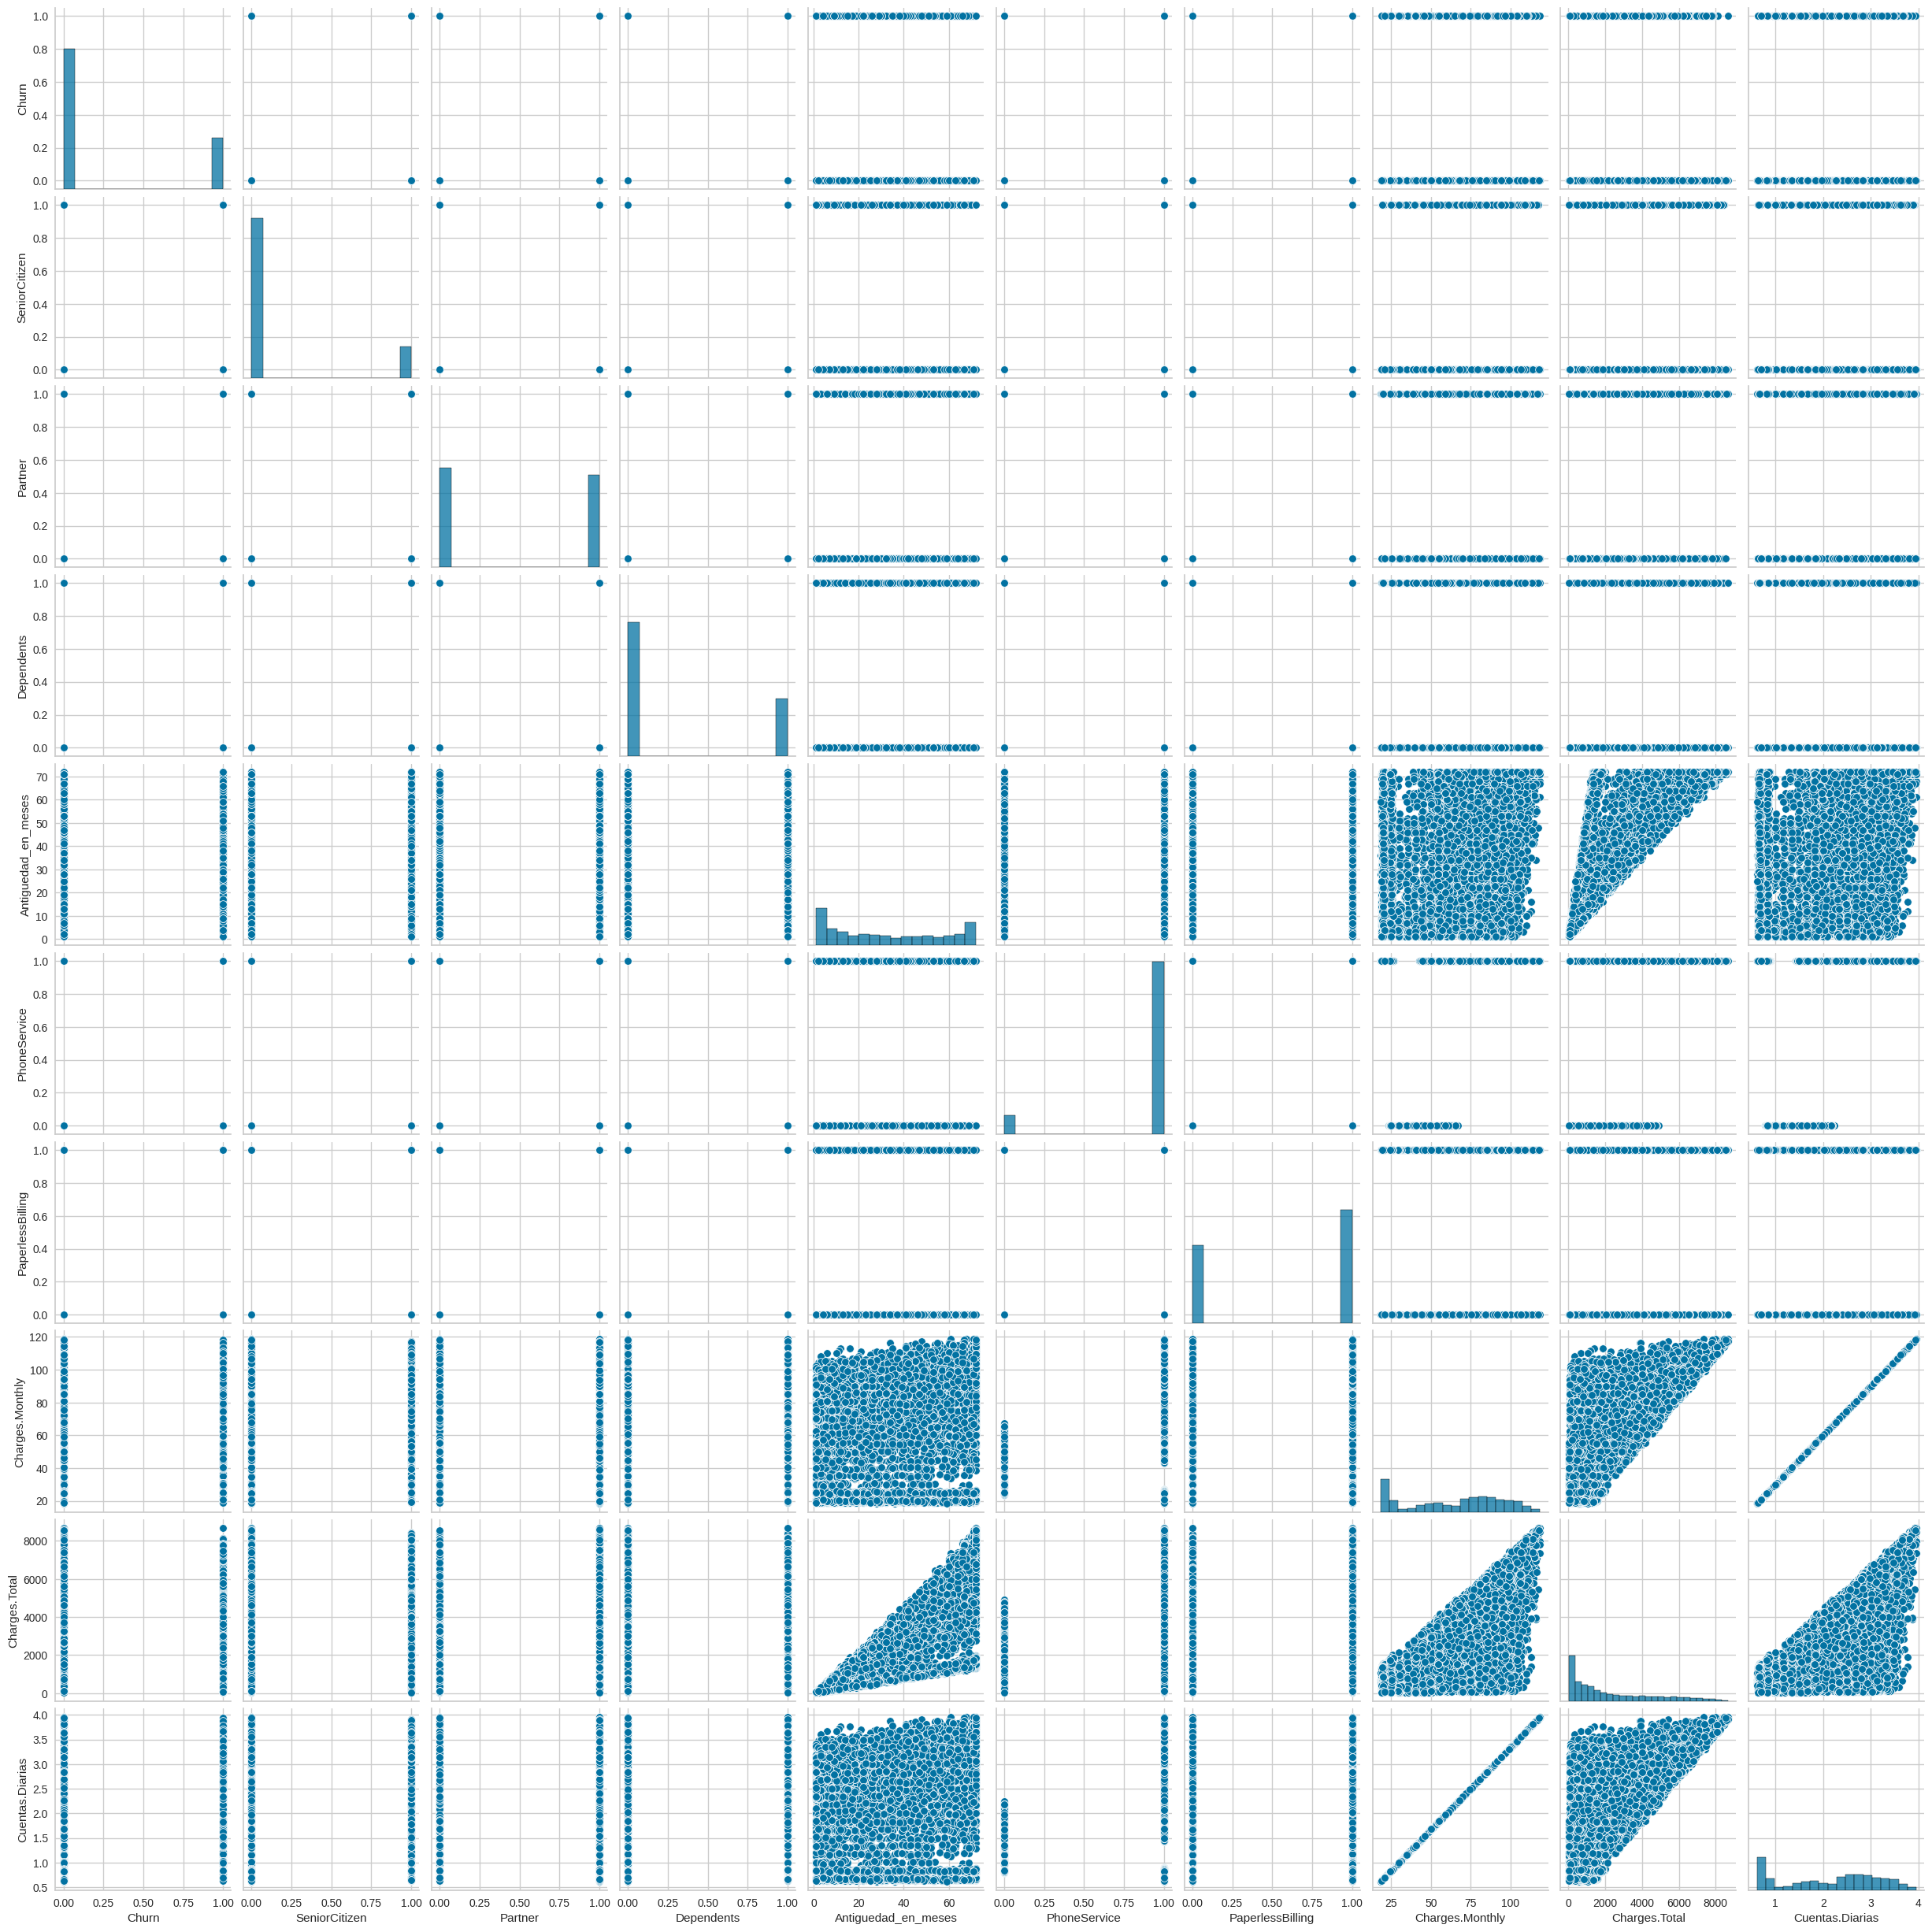

In [97]:
ax= sns.pairplot(datos)

#Transformacion del tipo de variables

In [109]:
datos.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Antiguedad_en_meses,0
PhoneService,0
MultipleLines,0
InternetService,0


In [100]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   Churn                7032 non-null   int64  
 2   gender               7032 non-null   int64  
 3   SeniorCitizen        7032 non-null   int64  
 4   Partner              7032 non-null   int64  
 5   Dependents           7032 non-null   int64  
 6   Antiguedad_en_meses  7032 non-null   int64  
 7   PhoneService         7032 non-null   int64  
 8   MultipleLines        7032 non-null   object 
 9   InternetService      7032 non-null   object 
 10  OnlineSecurity       7032 non-null   object 
 11  OnlineBackup         7032 non-null   object 
 12  DeviceProtection     7032 non-null   object 
 13  TechSupport          7032 non-null   object 
 14  StreamingTV          7032 non-null   object 
 15  StreamingMovies      7032 non-null   o

In [116]:
datos.columns.unique()

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Antiguedad_en_meses', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas.Diarias'],
      dtype='object')

Verifico los valores unicos dentro de las columnas

In [123]:
for i in datos.columns:
      print(f'{[i]} {datos[i].unique()}')


['customerID'] ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
['Churn'] [0 1]
['gender'] [0 1]
['SeniorCitizen'] [0 1]
['Partner'] [1 0]
['Dependents'] [1 0]
['Antiguedad_en_meses'] [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
['PhoneService'] [1 0]
['MultipleLines'] ['No' 'Yes']
['InternetService'] ['DSL' 'Fiber optic' 'No']
['OnlineSecurity'] ['No' 'Yes']
['OnlineBackup'] ['Yes' 'No']
['DeviceProtection'] ['No' 'Yes']
['TechSupport'] ['Yes' 'No']
['StreamingTV'] ['Yes' 'No']
['StreamingMovies'] ['No' 'Yes']
['Contract'] ['One year' 'Month-to-month' 'Two year']
['PaperlessBilling'] [1 0]
['PaymentMethod'] ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
['Charges.Monthly'] [65.6  59.9  73.9  ... 91.75 68.8  67.85]
['Charges.Total'] [ 

In [101]:
datos['gender'] = datos['gender'].replace({'Female':0,'Male':1})
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas.Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


#CODIFICANDO las variables categoricas

In [125]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})


In [126]:
cols_to_fix = [
    'MultipleLines'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No phone service': 'No'})

In [127]:
datos.MultipleLines.unique()

array(['No', 'Yes'], dtype=object)

In [129]:
datos.InternetService.unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [130]:
datos.Contract.unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [131]:
datos.PaymentMethod.unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

Y probamos con todas las variables.

In [132]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   Churn                7032 non-null   int64  
 2   gender               7032 non-null   int64  
 3   SeniorCitizen        7032 non-null   int64  
 4   Partner              7032 non-null   int64  
 5   Dependents           7032 non-null   int64  
 6   Antiguedad_en_meses  7032 non-null   int64  
 7   PhoneService         7032 non-null   int64  
 8   MultipleLines        7032 non-null   object 
 9   InternetService      7032 non-null   object 
 10  OnlineSecurity       7032 non-null   object 
 11  OnlineBackup         7032 non-null   object 
 12  DeviceProtection     7032 non-null   object 
 13  TechSupport          7032 non-null   object 
 14  StreamingTV          7032 non-null   object 
 15  StreamingMovies      7032 non-null   o

In [133]:
categoricas = ['InternetService','Contract','PaymentMethod','MultipleLines', 'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

In [134]:
#codificamos estas variables con 0 y 1

pd.get_dummies(data=datos,columns=categoricas,dtype=int).head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,0002-ORFBO,0,0,0,1,1,9,1,1,65.6,...,0,1,1,0,0,1,0,1,1,0
1,0003-MKNFE,0,1,0,0,0,9,1,0,59.9,...,1,0,1,0,1,0,1,0,0,1
2,0004-TLHLJ,1,1,0,0,0,4,1,1,73.9,...,1,0,0,1,1,0,1,0,1,0
3,0011-IGKFF,1,1,1,1,0,13,1,1,98.0,...,0,1,0,1,1,0,0,1,0,1
4,0013-EXCHZ,1,0,1,1,0,3,1,1,83.9,...,1,0,1,0,0,1,0,1,1,0


In [135]:
datos_codificados= pd.get_dummies(data=datos,columns=categoricas,dtype=int)
datos_codificados.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
5987,8464-EETCQ,0,1,0,0,0,57,1,0,18.80,...,1,0,1,0,1,0,1,0,1,0
5393,7613-LLQFO,1,1,0,0,0,12,1,1,84.45,...,1,0,1,0,1,0,0,1,1,0
1936,2812-SFXMJ,0,1,0,0,1,1,1,0,20.05,...,1,0,1,0,1,0,1,0,1,0
5262,7434-SHXLS,1,0,0,0,0,1,1,0,20.90,...,1,0,1,0,1,0,1,0,1,0
2740,3908-BLSYF,1,0,0,0,0,6,1,0,83.90,...,1,0,0,1,1,0,1,0,0,1


In [136]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7032 non-null   object 
 1   Churn                                    7032 non-null   int64  
 2   gender                                   7032 non-null   int64  
 3   SeniorCitizen                            7032 non-null   int64  
 4   Partner                                  7032 non-null   int64  
 5   Dependents                               7032 non-null   int64  
 6   Antiguedad_en_meses                      7032 non-null   int64  
 7   PhoneService                             7032 non-null   int64  
 8   PaperlessBilling                         7032 non-null   int64  
 9   Charges.Monthly                          7032 non-null   float64
 10  Charges.Total                            7032 no

de 21 columnas pasamos a 36 pero mas faciles de analizar

In [140]:
for i in datos_codificados.columns:
      print(f'{[i]} {datos_codificados[i].unique()}')


['customerID'] ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
['Churn'] [0 1]
['gender'] [0 1]
['SeniorCitizen'] [0 1]
['Partner'] [1 0]
['Dependents'] [1 0]
['Antiguedad_en_meses'] [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
['PhoneService'] [1 0]
['PaperlessBilling'] [1 0]
['Charges.Monthly'] [65.6  59.9  73.9  ... 91.75 68.8  67.85]
['Charges.Total'] [ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]
['Cuentas.Diarias'] [2.18666667 1.99666667 2.46333333 ... 3.05833333 2.29333333 2.26166667]
['InternetService_DSL'] [1 0]
['InternetService_Fiber optic'] [0 1]
['InternetService_No'] [0 1]
['Contract_Month-to-month'] [0 1]
['Contract_One year'] [1 0]
['Contract_Two year'] [0 1]
['PaymentMethod_Bank transfer (automatic)'] [0 1]
['PaymentMethod_Credit card (automatic)'] [0 1]

#LIMPIANDO LOS DATOS

In [141]:
datos_codificados.drop(columns=['customerID'],inplace=True)

In [142]:
datos_codificados.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,0,0,0,1,1,9,1,1,65.6,593.30,...,0,1,1,0,0,1,0,1,1,0
1,0,1,0,0,0,9,1,0,59.9,542.40,...,1,0,1,0,1,0,1,0,0,1
2,1,1,0,0,0,4,1,1,73.9,280.85,...,1,0,0,1,1,0,1,0,1,0
3,1,1,1,1,0,13,1,1,98.0,1237.85,...,0,1,0,1,1,0,0,1,0,1
4,1,0,1,1,0,3,1,1,83.9,267.40,...,1,0,1,0,0,1,0,1,1,0


In [143]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 35 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7032 non-null   int64  
 1   gender                                   7032 non-null   int64  
 2   SeniorCitizen                            7032 non-null   int64  
 3   Partner                                  7032 non-null   int64  
 4   Dependents                               7032 non-null   int64  
 5   Antiguedad_en_meses                      7032 non-null   int64  
 6   PhoneService                             7032 non-null   int64  
 7   PaperlessBilling                         7032 non-null   int64  
 8   Charges.Monthly                          7032 non-null   float64
 9   Charges.Total                            7032 non-null   float64
 10  Cuentas.Diarias                          7032 no

#Evaluando las correlaciones

In [144]:
datos_codificados.corr()

,Churn,gender,SeniorCitizen,Partner,Dependents,Antiguedad_en_meses,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
Churn,1.000000,-0.008545,0.150541,-0.149982,-0.163128,-0.354049,0.011691,0.191454,0.192858,-0.199484,...,0.082307,-0.082307,0.066193,-0.066193,0.164716,-0.164716,-0.063254,0.063254,-0.060860,0.060860
gender,-0.008545,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.011902,-0.013779,0.000048,...,0.013093,-0.013093,0.000807,-0.000807,0.008507,-0.008507,0.007124,-0.007124,0.010105,-0.010105
SeniorCitizen,0.150541,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.156258,0.219874,0.102411,...,-0.066663,0.066663,-0.059514,0.059514,0.060577,-0.060577,-0.105445,0.105445,-0.119842,0.119842
Partner,-0.149982,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,-0.013957,0.097825,0.319072,...,-0.141849,0.141849,-0.153556,0.153556,-0.120206,0.120206,-0.124483,0.124483,-0.118108,0.118108
Dependents,-0.163128,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.110131,-0.112343,0.064653,...,-0.023639,0.023639,-0.013900,0.013900,-0.063053,0.063053,0.016499,-0.016499,0.038375,-0.038375
Antiguedad_en_meses,-0.354049,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.004823,0.246862,0.825880,...,-0.361138,0.361138,-0.361520,0.361520,-0.325288,0.325288,-0.280264,0.280264,-0.285402,0.285402
PhoneService,0.011691,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,0.016696,0.248033,0.113008,...,0.052133,-0.052133,0.070076,-0.070076,0.095138,-0.095138,0.021383,-0.021383,0.033477,-0.033477
PaperlessBilling,0.191454,-0.011902,0.156258,-0.013957,-0.110131,0.004823,0.016696,1.000000,0.351930,0.157830,...,-0.127056,0.127056,-0.104079,0.104079,-0.037536,0.037536,-0.224241,0.224241,-0.211583,0.211583
Charges.Monthly,0.192858,-0.013779,0.219874,0.097825,-0.112343,0.246862,0.248033,0.351930,1.000000,0.651065,...,-0.441529,0.441529,-0.482607,0.482607,-0.338301,0.338301,-0.629668,0.629668,-0.627235,0.627235
Charges.Total,-0.199484,0.000048,0.102411,0.319072,0.064653,0.825880,0.113008,0.157830,0.651065,1.000000,...,-0.510100,0.510100,-0.522881,0.522881,-0.432868,0.432868,-0.515709,0.515709,-0.519867,0.519867


In [145]:
correlations = datos_codificados.corr()['Churn'].sort_values(ascending=False)
display(correlations)

,Churn
Churn,1.000000
Contract_Month-to-month,0.404565
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
Cuentas.Diarias,0.192858
Charges.Monthly,0.192858
PaperlessBilling,0.191454
OnlineSecurity_No,0.171270
TechSupport_No,0.164716
SeniorCitizen,0.150541


Vemos la correlacion graficamente

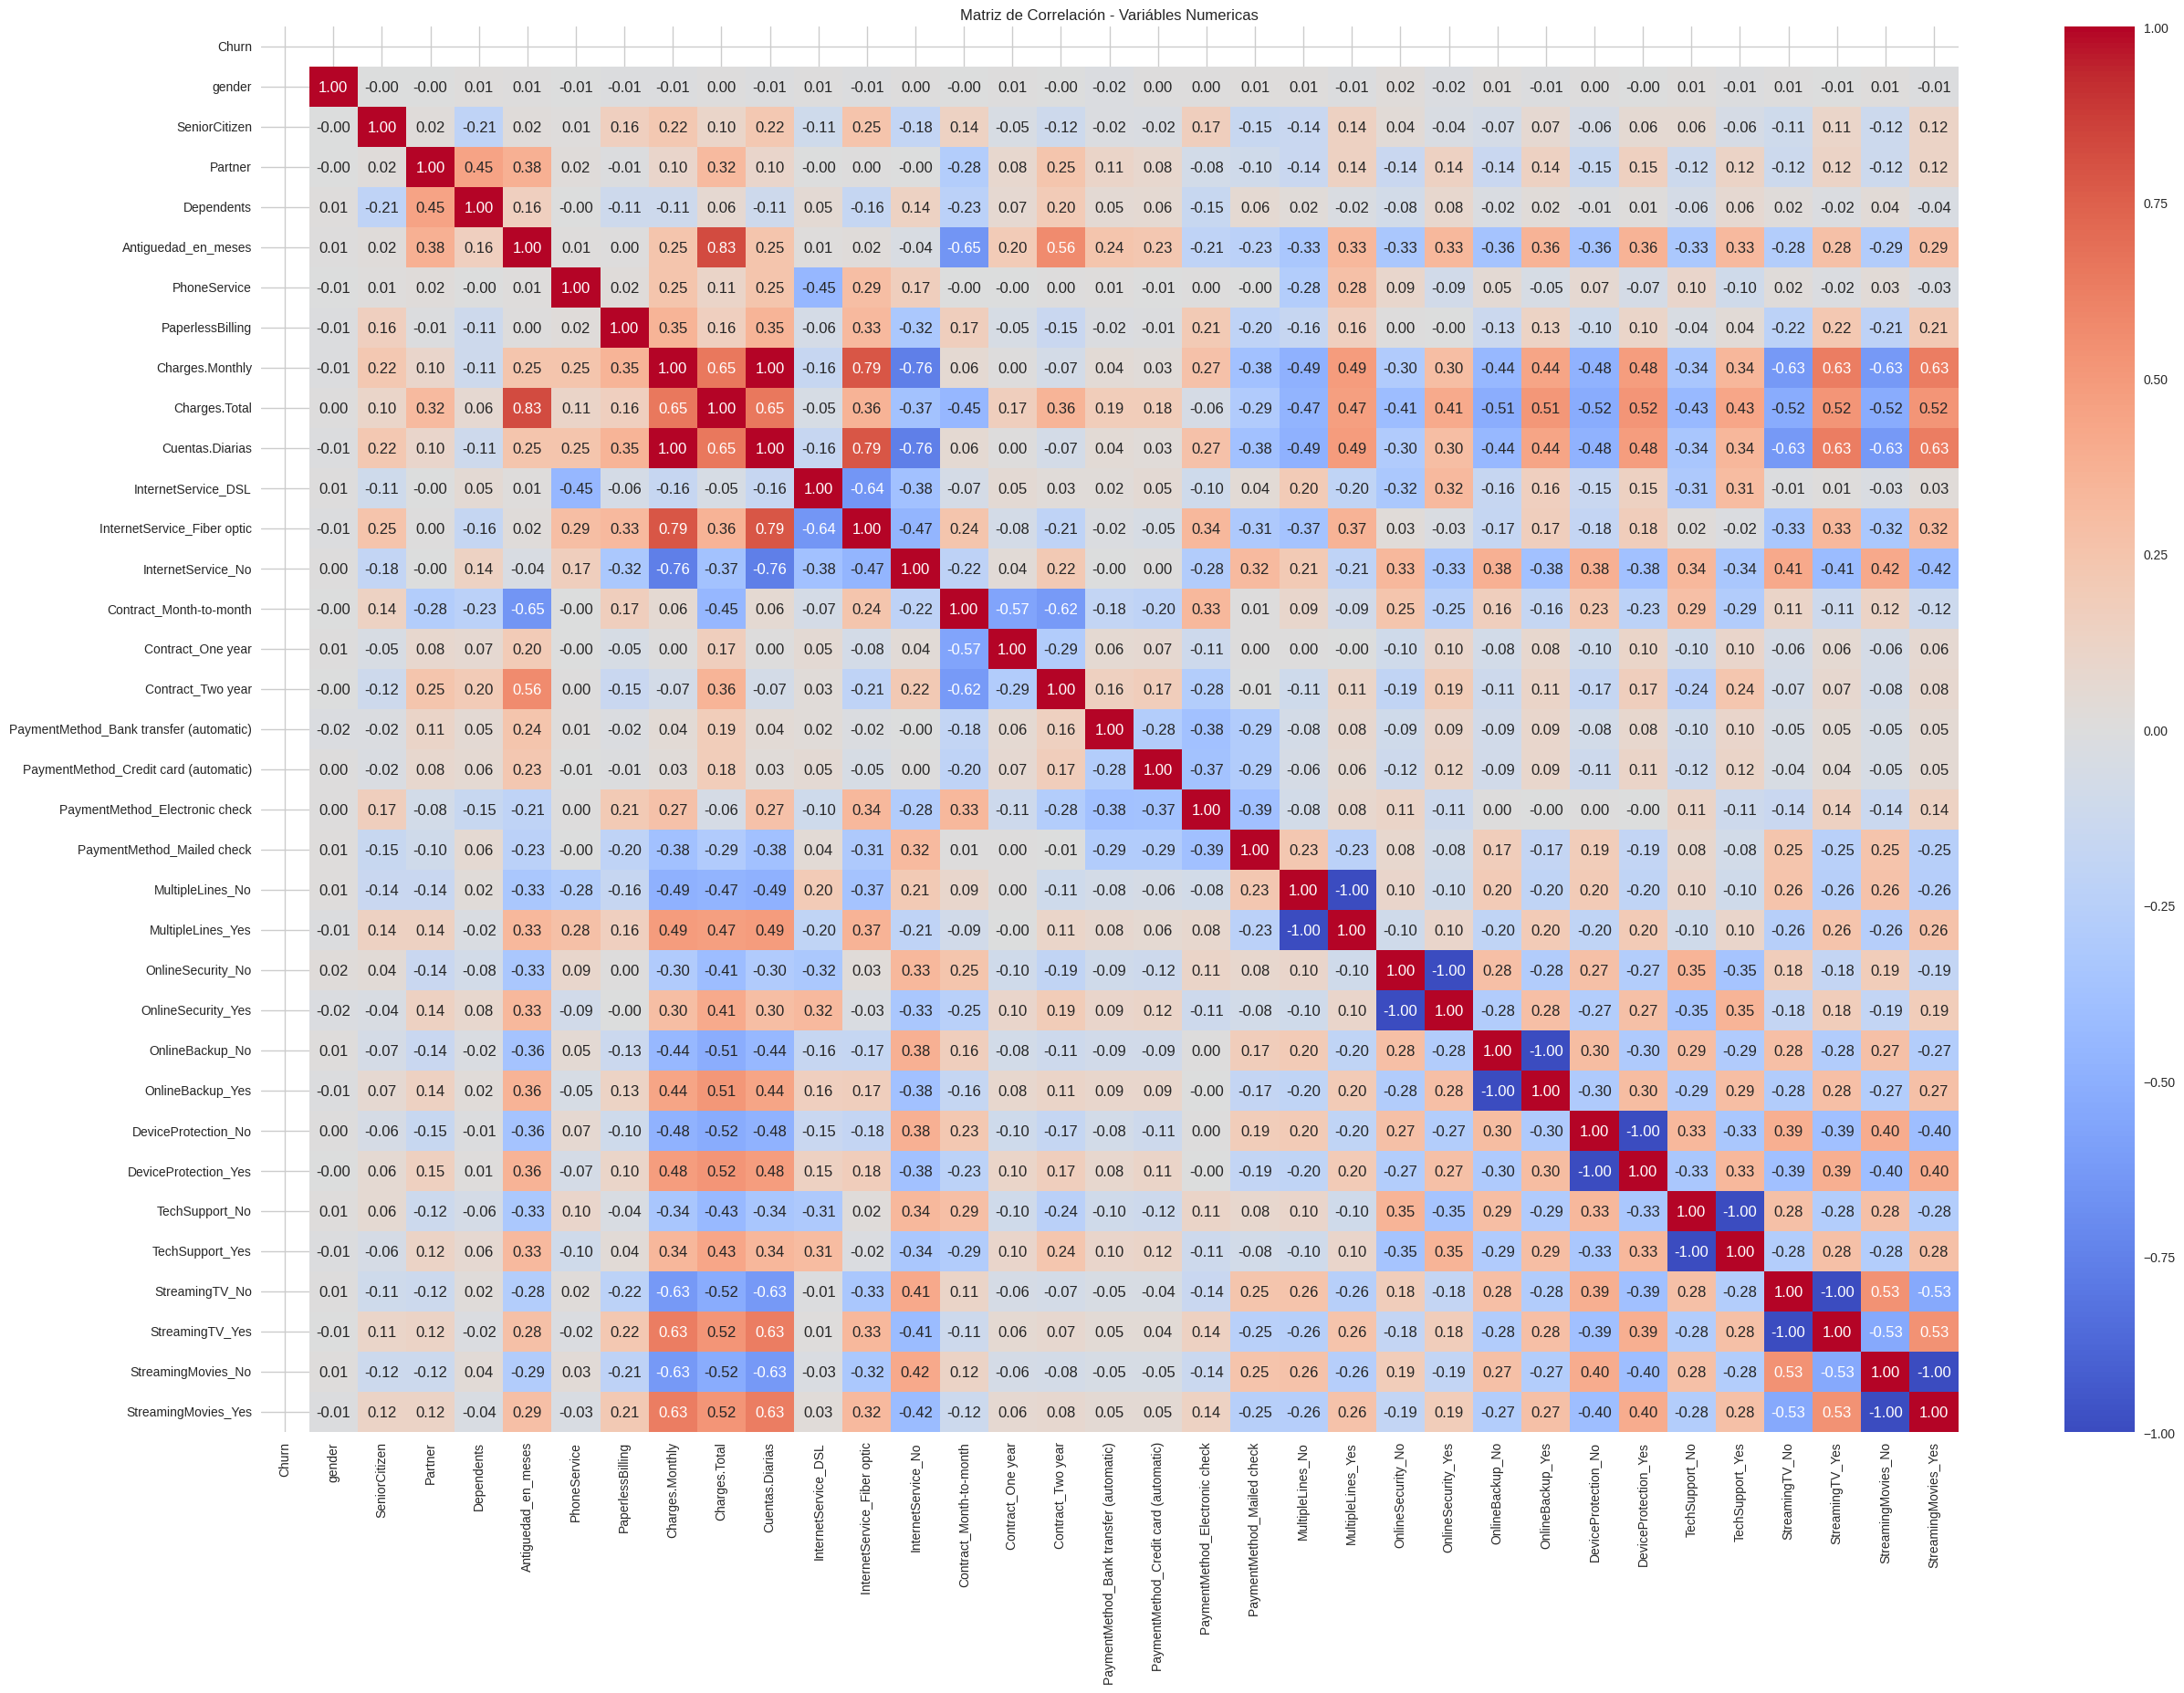

In [182]:
datos_numeric = datos_codificados.select_dtypes(include=["int64", "float64"])

datos_numeric["Churn"] = datos_codificados["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = datos_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(30,20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

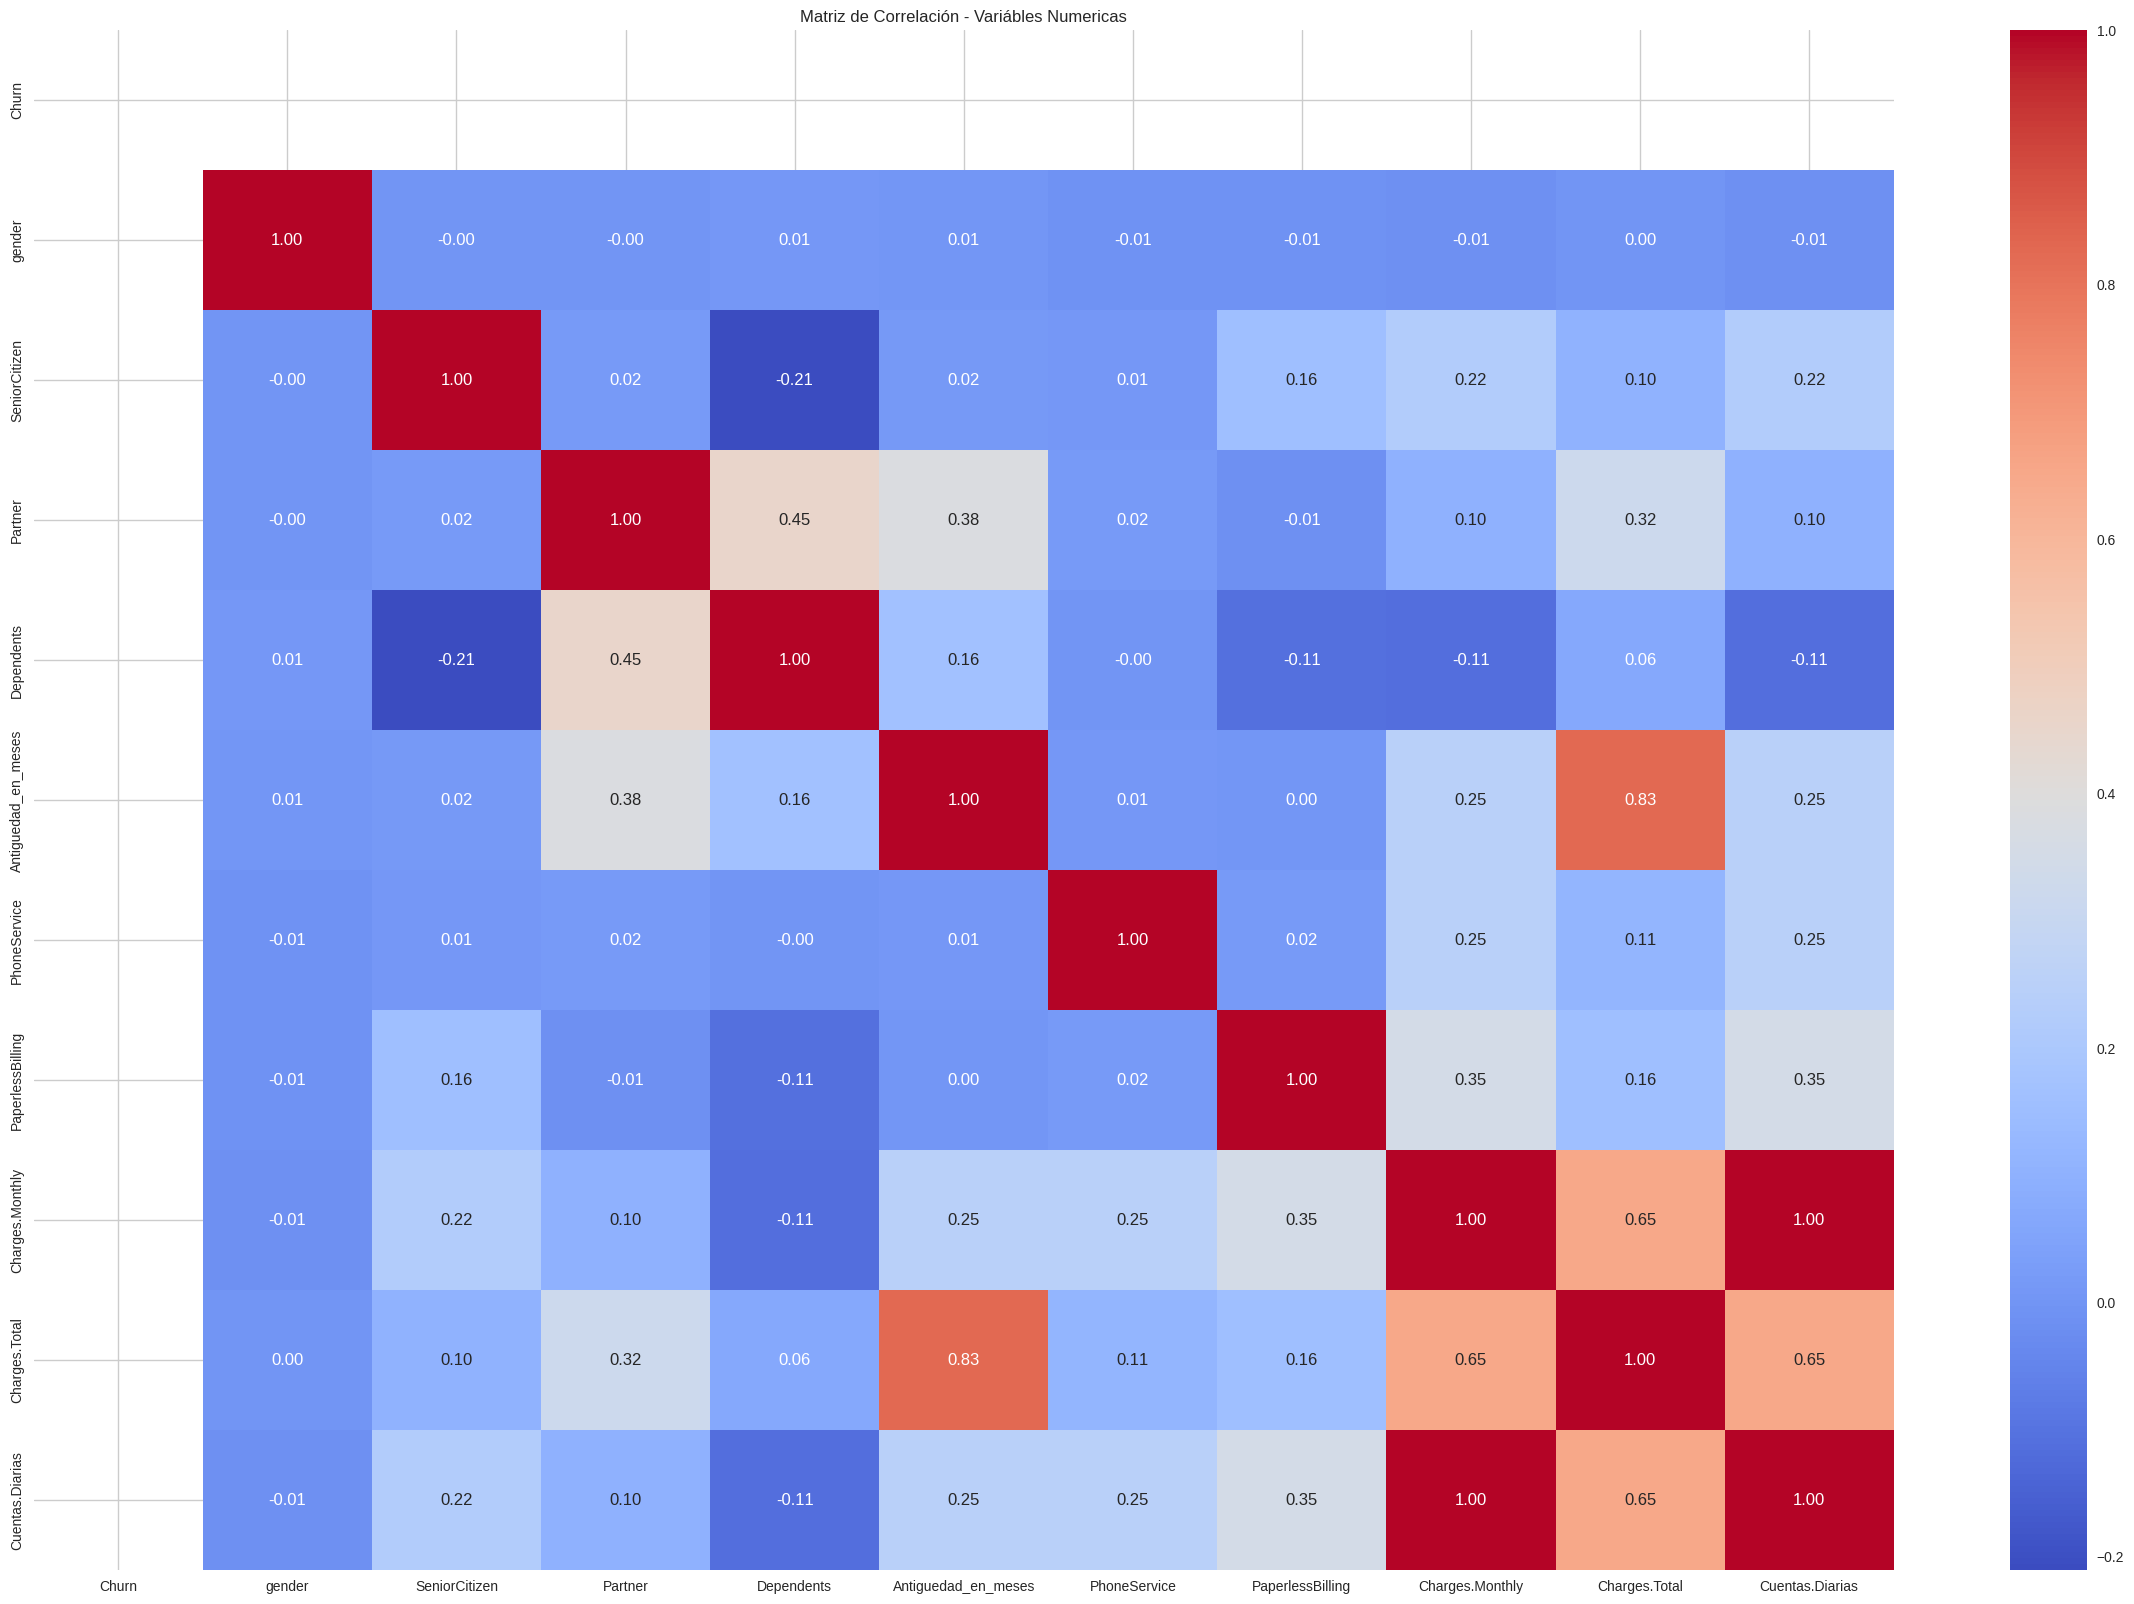

In [183]:
datos_numeric = datos.select_dtypes(include=["int64", "float64"])

datos_numeric["Churn"] = datos["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = datos_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(30,20))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [147]:
datos_codificados[['Churn','Charges.Total','Contract_Month-to-month','Contract_One year','Contract_Two year','Antiguedad_en_meses']].corr()

,Churn,Charges.Total,Contract_Month-to-month,Contract_One year,Contract_Two year,Antiguedad_en_meses
Churn,1.000000,-0.199484,0.404565,-0.178225,-0.301552,-0.354049
Charges.Total,-0.199484,1.000000,-0.446776,0.170569,0.358036,0.825880
Contract_Month-to-month,0.404565,-0.446776,1.000000,-0.570053,-0.621933,-0.649346
Contract_One year,-0.178225,0.170569,-0.570053,1.000000,-0.288843,0.202338
Contract_Two year,-0.301552,0.358036,-0.621933,-0.288843,1.000000,0.563801
Antiguedad_en_meses,-0.354049,0.825880,-0.649346,0.202338,0.563801,1.000000


#DEFINIENDO UNA BASELINE

Estaremos compando los dataos del modelo con este punto de partida

In [192]:
from sklearn.dummy import DummyClassifier

In [193]:
from sklearn.model_selection import train_test_split

In [194]:
x= datos_codificados.drop(['Churn'],axis=1) #todas las columnas menos churn → variables independientes
y= datos_codificados['Churn'] # → variable de respuesta

In [195]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=21)

In [196]:
baseline = DummyClassifier(strategy="most_frequent")#creamos nuestro modelo tipo dummy
baseline.fit(x_train,y_train) #entrenamos/ajustamos el modelo

DummyClassifier(strategy='most_frequent')

In [198]:
from sklearn.metrics import accuracy_score

In [199]:
y_pred_dummy = baseline.predict(x_test)

accuracy_score(y_test, y_pred_dummy)

0.7436018957345971

#Utilizamos ahora el modelo RandomForestClassifier

In [212]:
from sklearn.ensemble import RandomForestClassifier

In [213]:
modelo = RandomForestClassifier(random_state=21)

In [214]:
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=21
)

In [215]:
modelo.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=21)

In [216]:
y_pred=modelo.predict(x_test)

Evaluo modelo

In [217]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score


In [218]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8080568720379147
[[1436  133]
 [ 272  269]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1569
           1       0.67      0.50      0.57       541

    accuracy                           0.81      2110
   macro avg       0.75      0.71      0.72      2110
weighted avg       0.80      0.81      0.80      2110



In [219]:
importances = modelo.feature_importances_

feature_importances = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

In [220]:
feature_importances

,Feature,Importance
8,Charges.Total,0.147384
4,Antiguedad_en_meses,0.137143
9,Cuentas.Diarias,0.125131
7,Charges.Monthly,0.123999
13,Contract_Month-to-month,0.053678
18,PaymentMethod_Electronic check,0.029406
11,InternetService_Fiber optic,0.026231
6,PaperlessBilling,0.024124
0,gender,0.023569
15,Contract_Two year,0.023526


Mejorando el modelo


In [225]:
modelo = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=21
)

In [226]:
modelo.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=21)

In [227]:
y_pred=modelo.predict(x_test)

In [228]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8052132701421801
[[1440  129]
 [ 282  259]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1569
           1       0.67      0.48      0.56       541

    accuracy                           0.81      2110
   macro avg       0.75      0.70      0.72      2110
weighted avg       0.79      0.81      0.79      2110



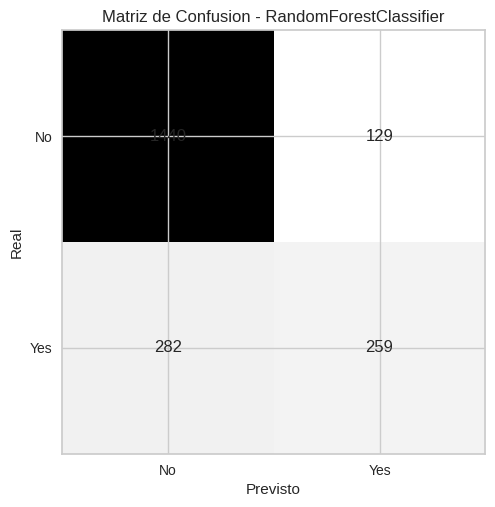

In [235]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - RandomForestClassifier")
plt.xlabel("Previsto")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

Análisis de la Importancia de las Variables

In [240]:
importancias = pd.DataFrame({
    "Variable": x_train.columns,
    "Importancia": modelo.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias

,Variable,Importancia
8,Charges.Total,0.132676
4,Antiguedad_en_meses,0.131601
9,Cuentas.Diarias,0.118173
7,Charges.Monthly,0.113532
13,Contract_Month-to-month,0.076808
15,Contract_Two year,0.041939
11,InternetService_Fiber optic,0.028880
18,PaymentMethod_Electronic check,0.028172
6,PaperlessBilling,0.021796
0,gender,0.020776


<Axes: ylabel='Variable'>

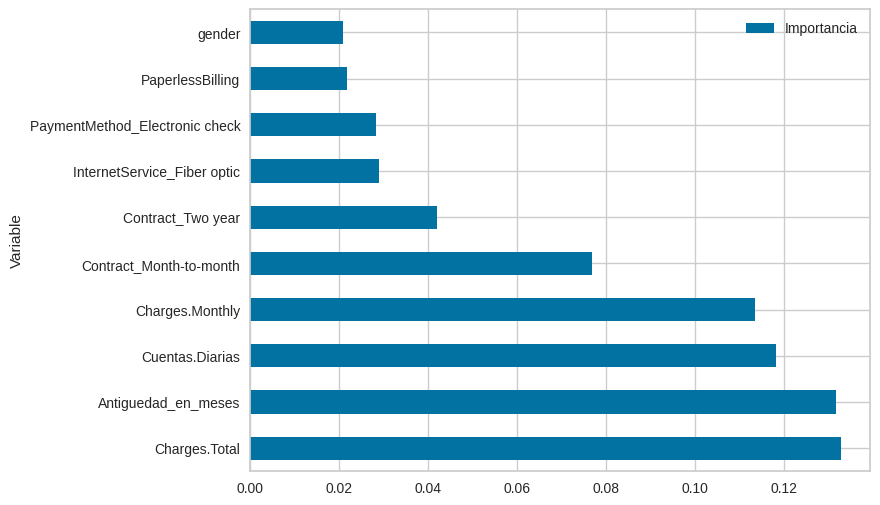

In [243]:
importancias.head(10).plot(
    x="Variable",
    y="Importancia",
    kind="barh",
    figsize=(8,6)
)

Utilizo el modelo de LogisticRegression

In [230]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

y_pred_log_normal = log_model.predict(x_test)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1569
           1       0.67      0.56      0.61       541

    accuracy                           0.82      2110
   macro avg       0.76      0.73      0.75      2110
weighted avg       0.81      0.82      0.81      2110



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Con clases balanceadas

In [231]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1569
           1       0.52      0.81      0.63       541

    accuracy                           0.76      2110
   macro avg       0.72      0.77      0.73      2110
weighted avg       0.82      0.76      0.77      2110



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [188]:
#Evaluo los modelos

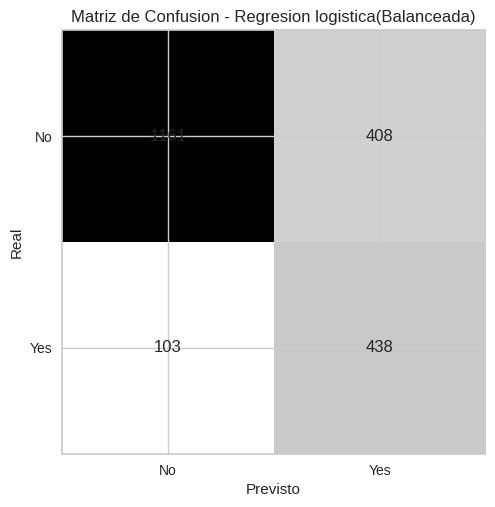

In [232]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica(Balanceada)")
plt.xlabel("Previsto")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

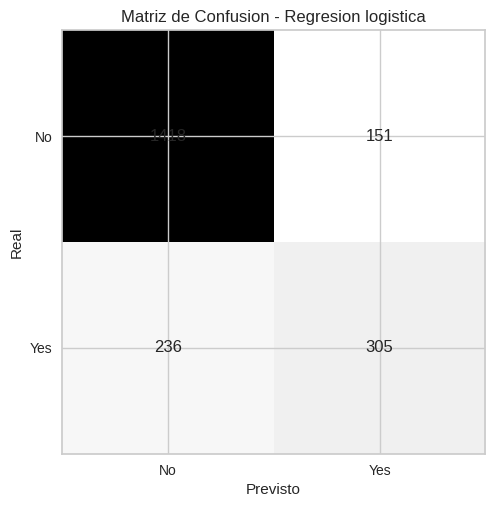

In [233]:
cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusion - Regresion logistica")
plt.xlabel("Previsto")
plt.ylabel("Real")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])

plt.show()

Análisis de la Importancia de las Variables

In [238]:
coeficientes = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente": log_model.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes

,Variable,Coeficiente
13,Contract_Month-to-month,0.737306
11,InternetService_Fiber optic,0.438362
6,PaperlessBilling,0.262523
18,PaymentMethod_Electronic check,0.233399
22,OnlineSecurity_No,0.188986
28,TechSupport_No,0.180494
24,OnlineBackup_No,0.136397
1,SeniorCitizen,0.116189
21,MultipleLines_Yes,0.101042
26,DeviceProtection_No,0.074293


<Axes: ylabel='Variable'>

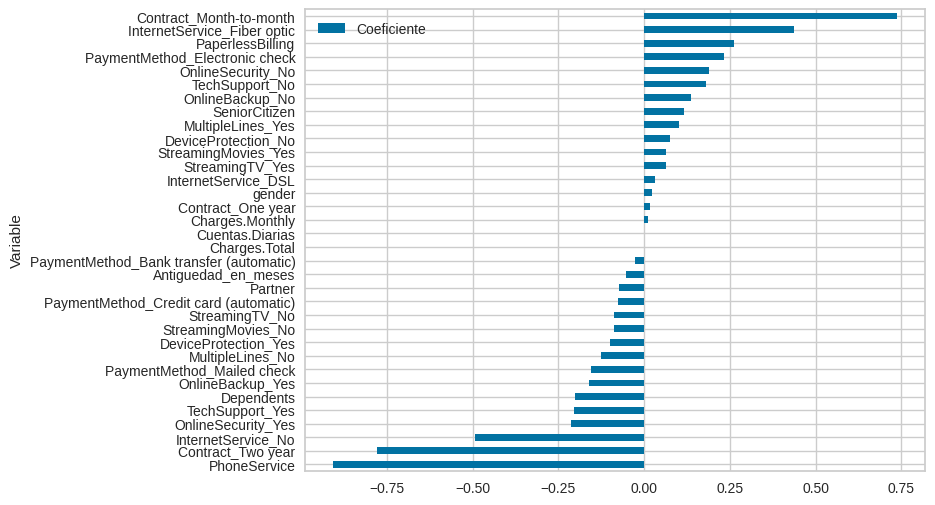

In [239]:
coeficientes.sort_values("Coeficiente").plot(
    x="Variable",
    y="Coeficiente",
    kind="barh",
    figsize=(8,6)
)

# Informe de análisis de cancelación de clientes (Churn)

## 1. Desempeño de los modelos

Para predecir la cancelación de clientes se utilizaron distintos modelos de clasificación:

- **Baseline (DummyClassifier)**: utilizado como referencia mínima, prediciendo siempre la clase más frecuente.
- **Regresión Logística**
- **Random Forest**
- Versiones **balanceadas** de ambos modelos para compensar el desbalance de clases.

Los resultados muestran que los modelos de **Regresión Logística y Random Forest superan claramente al modelo baseline**, lo que indica que las variables del dataset contienen información relevante para explicar la cancelación de clientes.

El modelo **Random Forest** tiene la capacidad de capturar relaciones no lineales entre variables, mientras que **Regresión Logística** permite interpretar con mayor claridad el impacto de cada variable en la probabilidad de cancelación.

---

## 2. Variables más relevantes en la predicción

### Regresión Logística

El análisis de los coeficientes del modelo permite identificar qué variables aumentan o disminuyen la probabilidad de cancelación.

**Factores que aumentan la cancelación:**

- **Contrato mensual (Month-to-Month):** los clientes con contratos mensuales presentan mayor probabilidad de cancelar el servicio.
- **Cargos mensuales altos (MonthlyCharges):** clientes con facturas más elevadas tienden a cancelar con mayor frecuencia.
- **Tipo de servicio de internet:** ciertos servicios con mayor costo pueden aumentar el riesgo de cancelación.

**Factores que reducen la cancelación:**

- **Antigüedad del cliente (Tenure):** cuanto mayor es el tiempo que un cliente permanece en la empresa, menor es la probabilidad de cancelación.
- **Contratos de largo plazo (One year / Two year):** los contratos más largos generan mayor fidelización.

---

### Random Forest

El modelo Random Forest permite analizar la **importancia de las variables**, es decir, cuánto contribuye cada variable a mejorar las predicciones del modelo.

Las variables más relevantes identificadas fueron:

- **Tenure (antigüedad del cliente)**
- **MonthlyCharges (cargo mensual)**
- **TotalCharges (gasto acumulado)**
- **Tipo de contrato**
- **Tipo de servicio de internet**

Esto indica que la duración de la relación con el cliente y el costo del servicio son factores determinantes en la cancelación.

---

## 3. Factores principales que afectan la cancelación

A partir del análisis de ambos modelos, los factores más influyentes en la cancelación de clientes son:

- Baja antigüedad del cliente.
- Contratos mensuales sin compromiso a largo plazo.
- Cargos mensuales elevados.
- Tipo de servicio contratado.
- Menor gasto acumulado en el servicio.

Estos resultados sugieren que los clientes nuevos, con mayor costo mensual y sin contratos a largo plazo, presentan mayor riesgo de cancelar el servicio.

---

## 4. Estrategias de retención recomendadas

En base a los resultados obtenidos se proponen las siguientes estrategias para reducir la cancelación de clientes:

**1. Incentivar contratos de largo plazo**

Ofrecer descuentos o beneficios a clientes que cambien de contratos mensuales a contratos de mayor duración.

**2. Programas de fidelización temprana**

Los primeros meses del cliente son críticos. Se recomienda implementar estrategias de acompañamiento, beneficios o promociones para clientes nuevos.

**3. Optimizar la estructura de precios**

Revisar los planes con cargos mensuales elevados para mejorar su competitividad y evitar cancelaciones.

**4. Identificación de clientes en riesgo**

Utilizar los modelos predictivos desarrollados para identificar clientes con alta probabilidad de cancelación y aplicar acciones de retención antes de que abandonen el servicio.

---

## 5. Conclusión

El análisis demuestra que es posible predecir la cancelación de clientes utilizando modelos de machine learning con resultados superiores al modelo baseline.

Las variables más influyentes están relacionadas principalmente con la **antigüedad del cliente, el tipo de contrato y los cargos mensuales**. Implementar estrategias orientadas a fortalecer la relación con clientes nuevos, incentivar contratos de largo plazo y optimizar los planes de servicio puede contribuir significativamente a reducir la tasa de cancelación.

